🚀 Usando la GPU: Tesla T4

--- 🧠 Comenzando Entrenamiento ---
Epoch [1/200] Batch 0/469 Loss: 70230.5469
Epoch [1/200] Batch 100/469 Loss: 27839.9141
Epoch [1/200] Batch 200/469 Loss: 24050.4043
Epoch [1/200] Batch 300/469 Loss: 22018.3984
Epoch [1/200] Batch 400/469 Loss: 20509.5918
Epoch [2/200] Batch 0/469 Loss: 20821.3242
Epoch [2/200] Batch 100/469 Loss: 19984.6914
Epoch [2/200] Batch 200/469 Loss: 18970.0586
Epoch [2/200] Batch 300/469 Loss: 18436.0879
Epoch [2/200] Batch 400/469 Loss: 17332.1680
Epoch [3/200] Batch 0/469 Loss: 17074.6582
Epoch [3/200] Batch 100/469 Loss: 17530.8496
Epoch [3/200] Batch 200/469 Loss: 17554.5527
Epoch [3/200] Batch 300/469 Loss: 16510.9609
Epoch [3/200] Batch 400/469 Loss: 16237.9551
Epoch [4/200] Batch 0/469 Loss: 16403.0840
Epoch [4/200] Batch 100/469 Loss: 15768.6543
Epoch [4/200] Batch 200/469 Loss: 16477.4902
Epoch [4/200] Batch 300/469 Loss: 16557.8105
Epoch [4/200] Batch 400/469 Loss: 15845.4512
Epoch [5/200] Batch 0/469 Loss: 15483.7324
Epo

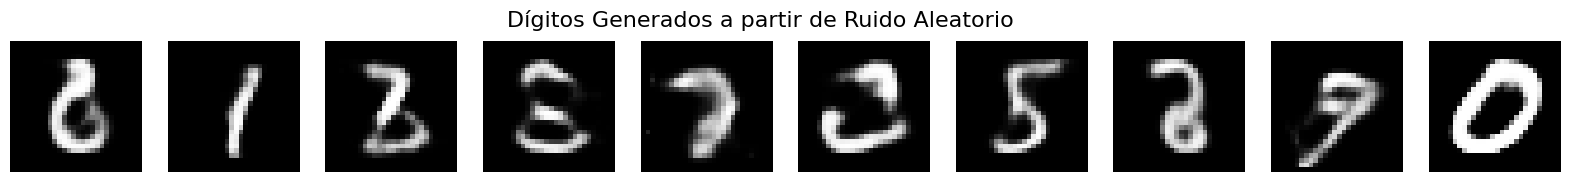

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Configuración de la GPU y Dispositivo ---
# Verifica si CUDA (la tecnología de NVIDIA para la GPU) está disponible
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("🚀 Usando la GPU:", torch.cuda.get_device_name(0))
else:
    device = torch.device("cpu")
    print("🐢 No se encontró GPU, usando la CPU.")

# --- 2. Definición del Modelo: Autoencoder Variacional (VAE) ---
class VAE(nn.Module):
    def __init__(self, input_dim=784, h_dim=200, z_dim=20):
        super().__init__()

        # --- ENCODER ---
        self.img_2hid = nn.Linear(input_dim, h_dim) # De imagen (784px) a capa oculta
        self.hid_2mu = nn.Linear(h_dim, z_dim)      # De capa oculta a la media (mu)
        self.hid_2sigma = nn.Linear(h_dim, z_dim)   # De capa oculta al log-varianza (log_sigma)

        # --- DECODER ---
        self.z_2hid = nn.Linear(z_dim, h_dim)       # De espacio latente (ruido, z) a capa oculta
        self.hid_2img = nn.Linear(h_dim, input_dim) # De capa oculta a imagen reconstruida (784px)

        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def encode(self, x):
        h = self.relu(self.img_2hid(x))
        mu = self.hid_2mu(h)
        log_sigma = self.hid_2sigma(h)
        return mu, log_sigma

    def decode(self, z):
        h = self.relu(self.z_2hid(z))
        return self.sigmoid(self.hid_2img(h))

    def forward(self, x):
        mu, log_sigma = self.encode(x)

        # Reparametrización: generar el vector 'z' a partir de mu y sigma
        # z = mu + sigma * epsilon (donde epsilon es ruido normal)
        sigma = torch.exp(0.5 * log_sigma)
        epsilon = torch.randn_like(sigma).to(device) # Ruido
        z = mu + sigma * epsilon

        x_reconstruida = self.decode(z)
        return x_reconstruida, mu, log_sigma

# --- 3. Preparación de Datos ---
# Transformaciones: convertir a tensor y aplanarlo para el VAE
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1)) # Aplana la imagen de 28x28 a un vector de 784
])

# Cargar el dataset MNIST
train_dataset = datasets.MNIST(root='dataset/', train=True, transform=transform, download=True)
train_loader = DataLoader(dataset=train_dataset, batch_size=128, shuffle=True)

# --- 4. Inicialización del Modelo, Pérdida y Optimizador ---
# Parámetros del modelo
INPUT_DIM = 784
H_DIM = 256     # Dimensión de la capa oculta
Z_DIM = 50      # Dimensión del espacio latente (el "ruido" que genera la imagen)
NUM_EPOCHS = 200
LEARNING_RATE = 5e-4

model = VAE(INPUT_DIM, H_DIM, Z_DIM).to(device) # Mueve el modelo a la GPU
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# --- 5. Definición de la Función de Pérdida del VAE ---
def vae_loss(x_reconstruida, x, mu, log_sigma):
    # Pérdida de Reconstrucción (MSE o BCE) - Cuánto se parece la imagen generada a la original
    BCE_loss = nn.BCELoss(reduction="sum")
    reconstruction_loss = BCE_loss(x_reconstruida, x)

    # Pérdida KL Divergence - Penaliza al encoder para asegurar que mu y sigma se parezcan a una distribución normal
    kl_divergence = -0.5 * torch.sum(1 + log_sigma - mu.pow(2) - log_sigma.exp())

    return reconstruction_loss + kl_divergence

# --- 6. Bucle de Entrenamiento ---
print("\n--- 🧠 Comenzando Entrenamiento ---")
for epoch in range(NUM_EPOCHS):
    for batch_idx, (data, _) in enumerate(train_loader):
        # Mueve los datos de entrada a la GPU
        data = data.to(device)

        # Forward
        x_reconstruida, mu, log_sigma = model(data)
        loss = vae_loss(x_reconstruida, data, mu, log_sigma)

        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if batch_idx % 100 == 0:
            print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] Batch {batch_idx}/{len(train_loader)} Loss: {loss.item():.4f}")

print("--- ✅ Entrenamiento Finalizado ---")
#



--- 🎨 Generando Dígitos ---


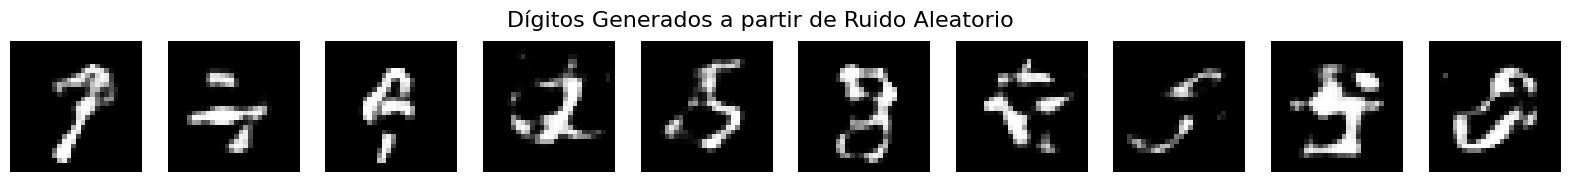

In [ ]:
# --- 7. Generación de Imágenes a partir de Ruido ---
def generate_images(model, num_images=10):
    model.eval() # Pone el modelo en modo de evaluación
    with torch.no_grad():
        # Genera 'ruido' aleatorio en el espacio latente (Z_DIM)
        noise = torch.randn(num_images, Z_DIM).to(device)
        # El decoder transforma el ruido en una imagen
        generated_images = model.decode(noise).view(num_images, 28, 28

                                                    ).cpu().numpy()

    # Muestra las imágenes
    fig, axes = plt.subplots(1, num_images, figsize=(num_images * 2, 2))
    for i in range(num_images):
        axes[i].imshow(generated_images[i], cmap='gray')
        axes[i].axis('off')

    fig.suptitle('Dígitos Generados a partir de Ruido Aleatorio', fontsize=16)
    plt.show()

print("\n--- 🎨 Generando Dígitos ---")
generate_images(model, num_images=10)